# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from dask.distributed import Client, progress
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

LAT_RANGE = (20, 50)  # degrees North
LON_RANGE_360 = (230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = (-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")


In [2]:
try:
    from dask.distributed import get_client
    get_client().close()
except Exception:
    pass

client = Client()  # set up local cluster on your laptop
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 31.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:50170,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:50198,Total threads: 4
Dashboard: http://127.0.0.1:50199/status,Memory: 7.80 GiB
Nanny: tcp://127.0.0.1:50173,


## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [3]:
air = xr.open_dataset(
                            TEMP_URL,
                            chunks={"time": 8},
                            )

precip = xr.open_dataset(
                            PRECIP_URL,
                            chunks={"time": 8},
                            )



## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [4]:
air

<xarray.Dataset> Size: 62MB
Dimensions:  (lat: 73, lon: 144, time: 1464)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 12kB 2020-01-01 ... 2020-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float32 62MB dask.array<chunksize=(8, 73, 144), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

In [5]:
# Setting the left, right, top and bottom bounds for the 
# continental US.

lon_bounds = (-125 + 360, -67 + 360)
lat_bounds = (50, 24)
time_period = 'Jun-2020'

air_us = air.sel(time = time_period, lat = slice(lat_bounds[0], lat_bounds[1]), lon = slice(lon_bounds[0], lon_bounds[1]))
precip_us = precip.sel(time = time_period, lat = slice(lat_bounds[0], lat_bounds[1]), lon = slice(lon_bounds[0], lon_bounds[1]))


## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [6]:
air_daily = air_us.resample(time = 'D').mean()


## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [7]:
air_interp = air_daily.interp(lon = precip_us.lon.values, lat = precip_us.lat.values, method = "linear")
air_interp = air_interp.air - 273.15 # converting air temp from K to C


In [8]:
air_interp

<xarray.DataArray 'air' (time: 30, lat: 52, lon: 116)> Size: 724kB
dask.array<sub, shape=(30, 52, 116), dtype=float32, chunksize=(1, 52, 116), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
  * lon      (lon) float32 464B 235.2 235.8 236.2 236.8 ... 291.8 292.2 292.8
  * lat      (lat) float32 208B 49.75 49.25 48.75 48.25 ... 25.25 24.75 24.25

## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [9]:
merged = xr.merge([air_interp, precip_us])



## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [10]:
# The interpolation leaves some NA's around the bottom and right border of the air temperature field
# so this code trims off those NA's.

merged = merged.sel(lat = slice(lat_bounds[0], lat_bounds[1] + 1), lon = slice(lon_bounds[0], lon_bounds[1]-1))

In [11]:
# The assertions below should pass once you have completed the exercise.
assert set(merged.data_vars) == {"air", "precip"}
assert merged.air.dims == merged.precip.dims
print(merged)


<xarray.Dataset> Size: 1MB
Dimensions:  (time: 30, lon: 114, lat: 50)
Coordinates:
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
  * lon      (lon) float32 456B 235.2 235.8 236.2 236.8 ... 290.8 291.2 291.8
  * lat      (lat) float32 200B 49.75 49.25 48.75 48.25 ... 26.25 25.75 25.25
Data variables:
    air      (time, lat, lon) float32 684kB dask.array<chunksize=(1, 50, 114), meta=np.ndarray>
    precip   (time, lat, lon) float32 684kB dask.array<chunksize=(8, 50, 114), meta=np.ndarray>


## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


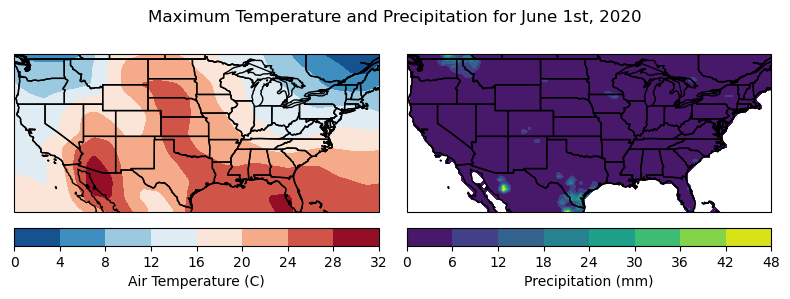

In [12]:
lon_grid, lat_grid = np.meshgrid(merged.lon.values, merged.lat.values)

fig, ax = plt.subplots(nrows= 1, ncols = 2, figsize = (8,16), subplot_kw={'projection': ccrs.PlateCarree()})

im1 = ax[0].contourf(lon_grid, lat_grid, merged.air.isel(time = 0).values, transform = ccrs.PlateCarree(), cmap = "RdBu_r")
ax[0].add_feature(cfeature.COASTLINE)
ax[0].add_feature(cfeature.BORDERS)
ax[0].add_feature(cfeature.STATES)

fig.colorbar(im1, ax = ax[0], location = "bottom", pad = 0.01, label = "Air Temperature (C)")

im2 = ax[1].contourf(lon_grid, lat_grid, merged.precip.isel(time = 0).values, transform = ccrs.PlateCarree())
ax[1].add_feature(cfeature.COASTLINE)
ax[1].add_feature(cfeature.BORDERS)
ax[1].add_feature(cfeature.STATES)
fig.colorbar(im2, ax = ax[1], location = "bottom", pad = 0.01, label = "Precipitation (mm)")

fig.suptitle("Maximum Temperature and Precipitation for June 1st, 2020", y = 0.29)
fig.tight_layout()



Text(0.5, 1.0, 'Comparison of Daily Air Temperatures Vs Precipitation Totals over the Continental US, June 2020 ')

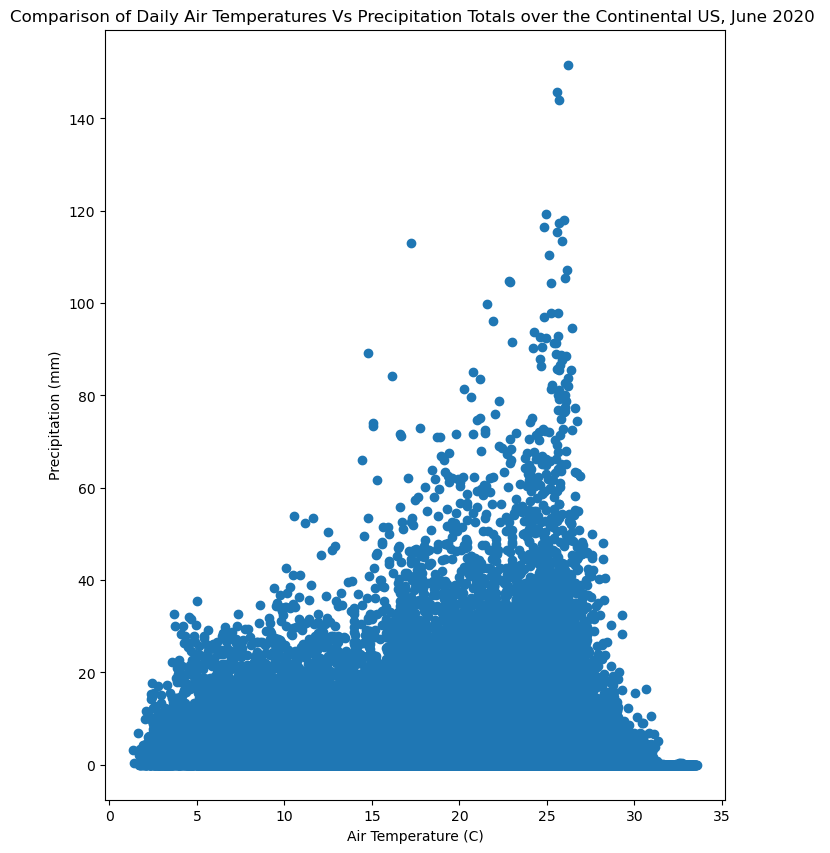

In [13]:
fig, ax = plt.subplots(nrows= 1, ncols = 1, figsize = (8,10))

ax.scatter(merged.air.values.flatten(), merged.precip.values.flatten())

ax.set_ylabel("Precipitation (mm)")
ax.set_xlabel("Air Temperature (C)")
ax.set_title("Comparison of Daily Air Temperatures Vs Precipitation Totals over the Continental US, June 2020 ")